## Exploratory Data Analysis and Root Cause Analysis for AtliQ Mart OTIF project. This notebook tests the remaining hypotheses established at project outset, diagnoses the structural drivers of service level failure, and clusters customers by failure profile. All findings feed directly into the recommendations layer and Power BI diagnostic page.

### Analytical Hypotheses

Before computing metrics, eight hypotheses were formed to guide root cause investigation. Each maps to a known supply chain failure mode. Results will be referenced throughout this notebook and the EDA notebook.
##### __H1 -> Forecast/Planning Failure:__ IF failures will cluster on specific SKUs rather than appearing randomly across all products. Under-forecasted SKUs will show disproportionately high IF failure rates.
##### __H2 -> Supplier Shortage:__ IF failures will appear simultaneously across multiple customers ordering the same SKU in the same week, indicating an AtliQ-side supply constraint rather than a customer-specific issue.
##### __H3 -> Warehouse/Fulfilment Error:__ A persistent background rate of small, random IF failures will remain after stripping out SKU-clustered and date-clustered failures, implicating warehouse execution errors.
##### __H4 -> Transportation Issues:__ OT failure rates will be significantly higher in one or more specific cities, pointing to city-level transport as the bottleneck rather than upstream dispatch or planning.
##### __H5 -> Over-Promising:__ Orders with shorter promise windows (agreed delivery date minus order placement date) will show higher OT failure rates, indicating AtliQ commits to lead times it cannot reliably meet.
##### __H6 -> Customer-Side Date Changes:__ Untestable with current data. The dataset captures only the final agreed delivery date, not its history. Recommended for future investigation if AtliQ provides order change logs.
##### __H7 -> Festival Demand Spike:__ IF failure rates will dip sharply in weeks preceding major Indian festivals within the data window (Holi - March, Eid - May, Raksha Bandhan - August), indicating planning does not account for seasonal demand surges.
##### __H8 -> Month-End Capacity Rush:__ OTIF will dip in the last 5 days of each month due to back-loaded shipment volumes as sales teams push to hit monthly quotas.
Hypothesis testing is conducted across 03_core_metrics.ipynb and 04_eda_and_rca.ipynb with findings reported against pre-defined confirmation thresholds.

#### *Loading the master dataframe and supporting metric outputs produced by 02_cleaning.ipynb and 03_core_metrics.ipynb. All transformations and feature engineering are already applied.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
#Output Formatting Settings and Project Directory Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')

CLEAN_DIR  = r"E:\Portfolio_Projects\Supply_Chain_FMCG\cleaned"
OUTPUT_DIR = r"E:\Portfolio_Projects\Supply_Chain_FMCG\outputs"

In [5]:
#Loading files
master = pd.read_csv(
    os.path.join(CLEAN_DIR, 'master.csv'),
    parse_dates=['order_placement_date',
                 'agreed_delivery_date',
                 'actual_delivery_date'])

fact_orders_agg = pd.read_csv(
    os.path.join(CLEAN_DIR, 'fact_orders_agg.csv'),
    parse_dates=['order_placement_date'])

customer_metrics = pd.read_csv(
    os.path.join(OUTPUT_DIR, 'customer_metrics.csv'))

product_metrics = pd.read_csv(
    os.path.join(OUTPUT_DIR, 'product_metrics.csv'))

dim_customers = pd.read_csv(
    os.path.join(CLEAN_DIR, 'dim_customers.csv'))

print("LOADED SUCCESSFULLY\n")
print(f"  master           : {master.shape}")
print(f"  fact_orders_agg  : {fact_orders_agg.shape}")
print(f"  customer_metrics : {customer_metrics.shape}")
print(f"  product_metrics  : {product_metrics.shape}")
print(f"  dim_customers    : {dim_customers.shape}")

LOADED SUCCESSFULLY

  master           : (57096, 25)
  fact_orders_agg  : (31729, 6)
  customer_metrics : (35, 16)
  product_metrics  : (18, 10)
  dim_customers    : (35, 3)


#### *01. Analyzing the distribution of delivery delays across all order lines. Days late is computed as actual delivery date minus agreed delivery date. Positive values indicate late delivery, zero indicates on time, negative indicates early delivery. This distribution reveals whether AtliQ's OT failures are concentrated in minor delays or spread across severe ones.*

__Delivery delay distribution__

- Days late summary statistics

In [6]:
print("DAYS LATE - DISTRIBUTION SUMMARY\n")
print(master['days_late'].value_counts().sort_index().to_string())

print(f"\nTotal order lines        : {len(master):,}")
print(f"Delivered early (< 0)    : {(master['days_late'] < 0).sum():,} ({(master['days_late'] < 0).mean()*100:.2f}%)")
print(f"Delivered on time (= 0)  : {(master['days_late'] == 0).sum():,} ({(master['days_late'] == 0).mean()*100:.2f}%)")
print(f"Delivered late (> 0)     : {(master['days_late'] > 0).sum():,} ({(master['days_late'] > 0).mean()*100:.2f}%)")
print(f"\nAmong late deliveries:")
late = master[master['days_late'] > 0]
print(f"  1 day late             : {(late['days_late'] == 1).sum():,} ({(late['days_late'] == 1).sum()/len(late)*100:.2f}% of late)")
print(f"  2 days late            : {(late['days_late'] == 2).sum():,} ({(late['days_late'] == 2).sum()/len(late)*100:.2f}% of late)")
print(f"  3 days late            : {(late['days_late'] == 3).sum():,} ({(late['days_late'] == 3).sum()/len(late)*100:.2f}% of late)")

DAYS LATE - DISTRIBUTION SUMMARY

days_late
-1     3607
 0    36998
 1     8255
 2     5136
 3     3100

Total order lines        : 57,096
Delivered early (< 0)    : 3,607 (6.32%)
Delivered on time (= 0)  : 36,998 (64.80%)
Delivered late (> 0)     : 16,491 (28.88%)

Among late deliveries:
  1 day late             : 8,255 (50.06% of late)
  2 days late            : 5,136 (31.14% of late)
  3 days late            : 3,100 (18.80% of late)


- Visualizing delay distribution

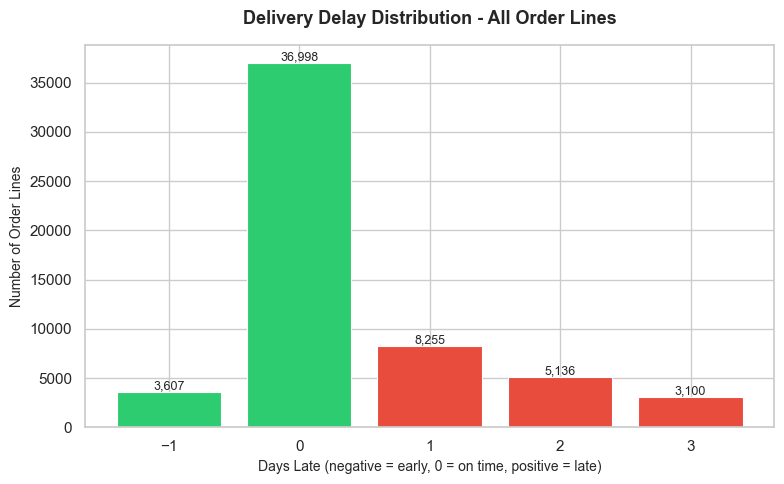

Chart saved


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

delay_counts = master['days_late'].value_counts().sort_index()
colors = ['#2ecc71' if x <= 0 else '#e74c3c' for x in delay_counts.index]

ax.bar(delay_counts.index, delay_counts.values, color=colors, edgecolor='white', linewidth=0.8)

ax.set_title('Delivery Delay Distribution - All Order Lines', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Days Late (negative = early, 0 = on time, positive = late)', fontsize=10)
ax.set_ylabel('Number of Order Lines', fontsize=10)

for i, (x, y) in enumerate(zip(delay_counts.index, delay_counts.values)):
    ax.annotate(f'{y:,}', xy=(x, y), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'delay_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

### Delivery delay analysis reveals that 64.80% of order lines are delivered on time at line level, versus 59.03% at order level - the gap explained by the strict all-or-nothing order-level OT criterion where one late line fails the entire order. Among the 28.88% of late lines, delays follow a clean descending pattern: 50% are one day late, 31% two days, 19% three days. This decay curve is characteristic of a capacity constraint rather than a logistics failure - when capacity is tight, most slippage is marginal. A logistics breakdown would produce a flatter, more uniform delay distribution. Additionally, 6.32% of lines arrived one day early, which in FMCG retail can disrupt retailer cold storage and shelf space planning - an operational finding worth surfacing to the logistics team.

#### *02. Testing H5 - whether shorter promise windows correlate with higher OT failure rates. If AtliQ is over-promising on lead time, orders with 1-day promise windows should show significantly worse OT performance than orders with 2 or 3 day windows. Promise window is computed as agreed delivery date minus order placement date.*

__H5 - Promise window vs OT failure__

- OT failure rate by promise window

In [8]:
pw_analysis = master.groupby('promise_window').agg(
    total_lines  = ('on_time_line', 'count'),
    ot_success   = ('on_time_line', 'sum')
).reset_index()

pw_analysis['OT_%']          = (pw_analysis['ot_success'] / pw_analysis['total_lines'] * 100).round(2)
pw_analysis['OT_failure_%']  = (100 - pw_analysis['OT_%']).round(2)

print("H5 TEST - PROMISE WINDOW VS OT PERFORMANCE\n")
print(f"  {'Promise Window':>15} {'Lines':>8} {'OT%':>8} {'OT Failure%':>12}")
print(f"  {'-'*48}")
for _, row in pw_analysis.iterrows():
    print(f"  {str(int(row['promise_window']))+' day(s)':>15} {row['total_lines']:>8,} {row['OT_%']:>8.2f} {row['OT_failure_%']:>12.2f}")

H5 TEST - PROMISE WINDOW VS OT PERFORMANCE

   Promise Window    Lines      OT%  OT Failure%
  ------------------------------------------------
         1 day(s) 18,965.0    70.94        29.06
         2 day(s) 19,137.0    71.15        28.85
         3 day(s) 18,994.0    71.26        28.74


- H5 Visualization

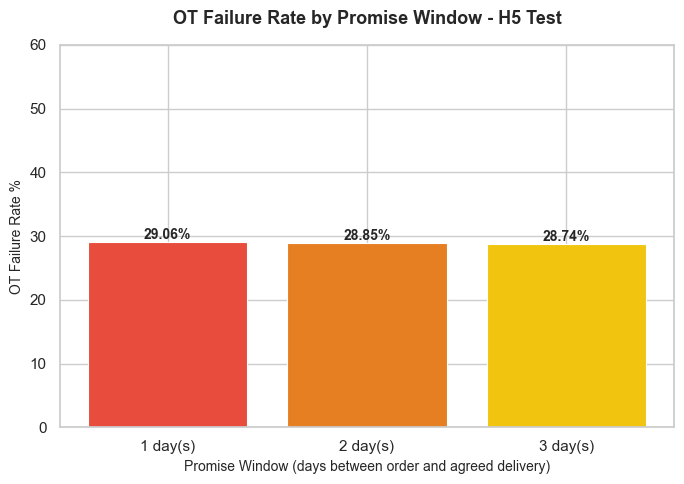

Chart saved.


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    pw_analysis['promise_window'].astype(str) + ' day(s)',
    pw_analysis['OT_failure_%'],
    color=['#e74c3c', '#e67e22', '#f1c40f'],
    edgecolor='white', linewidth=0.8
)

ax.set_title('OT Failure Rate by Promise Window - H5 Test', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Promise Window (days between order and agreed delivery)', fontsize=10)
ax.set_ylabel('OT Failure Rate %', fontsize=10)
ax.set_ylim(0, 60)

for _, row in pw_analysis.iterrows():
    ax.annotate(
        f"{row['OT_failure_%']}%",
        xy=(str(int(row['promise_window'])) + ' day(s)', row['OT_failure_%']),
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'h5_promise_window.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

### H5 rejected. OT failure rates across promise window bands are virtually identical i.e., 29.06% for 1-day windows, 28.85% for 2-day, and 28.74% for 3-day. The 0.32 percentage point spread is negligible and shows no directional relationship between lead time commitment and delivery performance. AtliQ is not failing because it over-promises - it is failing because its operational execution is unreliable regardless of the time window given. This finding eliminates a simple administrative fix and confirms the root cause lies within dispatch, supply, or warehouse operations.

#### *03. Testing H2 - whether IF failures cluster simultaneously across multiple customers ordering the same product in the same week. If a supplier failed AtliQ on a specific SKU in a specific week, multiple customers ordering that SKU that week would all experience IF failure together. This pattern is the fingerprint of a supply-side constraint rather than a customer-specific issue.*

__H2 - Simultaneous IF failures__

- Computing IF failure rate per product per week

In [11]:
product_week = master.groupby(
    ['product_name', 'category', 'order_week']
).agg(
    total_lines      = ('in_full_line', 'count'),
    failed_lines     = ('in_full_line', lambda x: (x == 0).sum()),
    distinct_customers = ('customer_id', 'nunique')
).reset_index()

product_week['if_failure_rate'] = (
    product_week['failed_lines'] /
    product_week['total_lines'] * 100
).round(2)

- Flagging high failure weeks

In [12]:
#High failure = IF failure rate above 50% AND 3+ customers affected
high_failure = product_week[
    (product_week['if_failure_rate'] >= 50) &
    (product_week['distinct_customers'] >= 3)
].copy()

print("H2 TEST - SIMULTANEOUS IF FAILURES\n")
print(f"  Total product-week combinations    : {len(product_week):,}")
print(f"  High failure combinations (>=50%,  ")
print(f"  3+ customers affected)             : {len(high_failure):,}")
print(f"  Percentage of combinations flagged : {len(high_failure)/len(product_week)*100:.2f}%")

print(f"\nTOP 15 WORST PRODUCT-WEEK COMBINATIONS\n")
top15 = high_failure.sort_values(
    ['if_failure_rate', 'distinct_customers'],
    ascending=[False, False]
).head(15)

print(f"  {'Product':<20} {'Category':<12} {'Week':>6} {'Failure%':>10} {'Customers':>10}")
print(f"  {'-'*62}")
for _, row in top15.iterrows():
    print(f"  {row['product_name']:<20} {row['category']:<12} {row['order_week']:>6} {row['if_failure_rate']:>10.2f} {row['distinct_customers']:>10.0f}")

H2 TEST - SIMULTANEOUS IF FAILURES

  Total product-week combinations    : 486
  High failure combinations (>=50%,  
  3+ customers affected)             : 1
  Percentage of combinations flagged : 0.21%

TOP 15 WORST PRODUCT-WEEK COMBINATIONS

  Product              Category       Week   Failure%  Customers
  --------------------------------------------------------------
  AM Ghee 150          Dairy            35      52.94         15


#### Lowering the failure rate threshold to 40% to understand the full landscape of simultaneous failures. One combination at 50% is insufficient to confirm or reject H2 - we need to see the distribution at multiple thresholds.

- Broader view at lower threshold

In [13]:
thresholds = [50, 40, 30]

print("H2 - FLAGGED COMBINATIONS AT MULTIPLE THRESHOLDS\n")
for t in thresholds:
    flagged = product_week[
        (product_week['if_failure_rate'] >= t) &
        (product_week['distinct_customers'] >= 3)
    ]
    print(f"  Threshold >= {t}% failure, 3+ customers : {len(flagged):,} combinations")

H2 - FLAGGED COMBINATIONS AT MULTIPLE THRESHOLDS

  Threshold >= 50% failure, 3+ customers : 1 combinations
  Threshold >= 40% failure, 3+ customers : 41 combinations
  Threshold >= 30% failure, 3+ customers : 420 combinations


- Distribution of distinct customers in high failure weeks

In [14]:
print(f"\nDISTRIBUTION - CUSTOMERS AFFECTED IN HIGH FAILURE WEEKS\n")
high_failure_30 = product_week[
    (product_week['if_failure_rate'] >= 30) &
    (product_week['distinct_customers'] >= 3)
].copy()

print(f"  Combinations at >=30% threshold    : {len(high_failure_30):,}")
print(f"\n  Customer count distribution:")
print(high_failure_30['distinct_customers'].value_counts().sort_index().to_string())


DISTRIBUTION - CUSTOMERS AFFECTED IN HIGH FAILURE WEEKS

  Combinations at >=30% threshold    : 420

  Customer count distribution:
distinct_customers
11      1
12      2
15      5
16      3
17      4
32      2
33     15
34    106
35    282


- Visualizing customer spread in flagged weeks

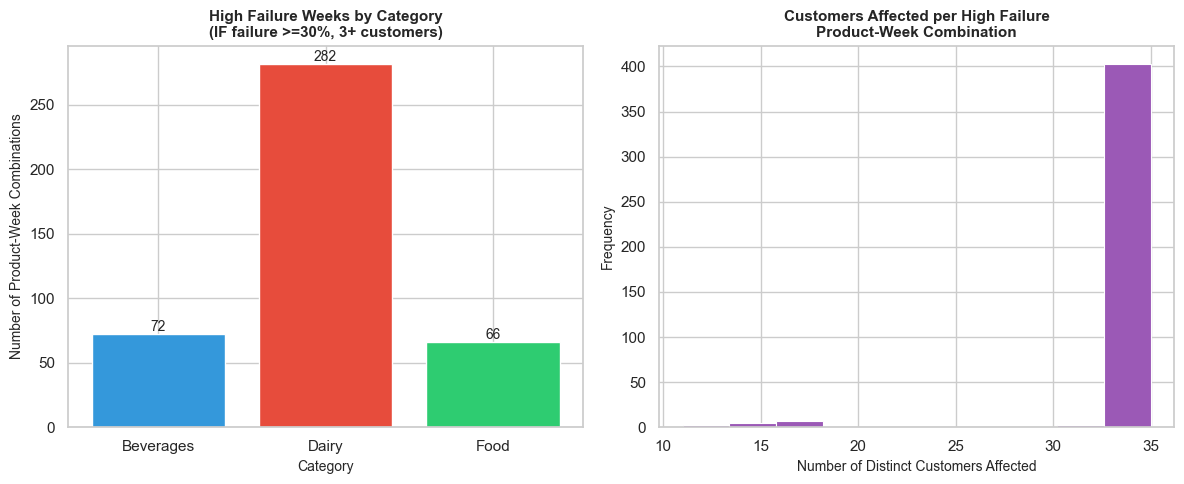

Chart saved.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left - flagged combinations by category
category_counts = high_failure_30.groupby('category').size()
axes[0].bar(
    category_counts.index,
    category_counts.values,
    color=['#3498db', '#e74c3c', '#2ecc71'],
    edgecolor='white'
)
axes[0].set_title('High Failure Weeks by Category\n(IF failure >=30%, 3+ customers)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=10)
axes[0].set_ylabel('Number of Product-Week Combinations', fontsize=10)

for i, (cat, val) in enumerate(category_counts.items()):
    axes[0].annotate(f'{val}', xy=(i, val), ha='center', va='bottom', fontsize=10)

# Right - distribution of customers affected per flagged combination
axes[1].hist(
    high_failure_30['distinct_customers'],
    bins=10, color='#9b59b6', edgecolor='white', linewidth=0.8
)
axes[1].set_title('Customers Affected per High Failure\nProduct-Week Combination', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Number of Distinct Customers Affected', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'h2_simultaneous_failures.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

#### Visualizing how the number of flagged product-week combinations changes across failure rate thresholds. The steep drop from 420 at 30% to 1 at 50% reveals that simultaneous failures are common at low severity but rare at high severity - inconsistent with a discrete supplier shortage event which would produce sharp, high-magnitude simultaneous failures.

- Threshold sensitivity visualization

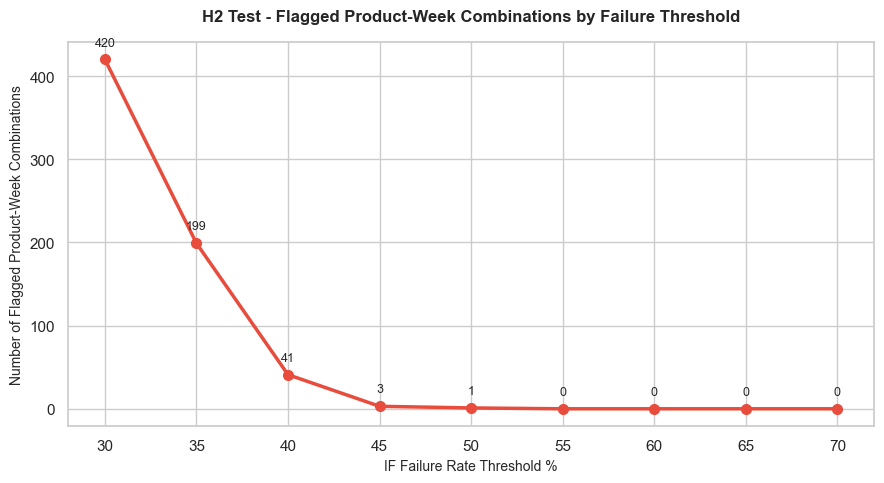

Chart saved.


In [18]:
thresholds_full = list(range(30, 75, 5))
flagged_counts  = []

for t in thresholds_full:
    count = len(product_week[
        (product_week['if_failure_rate'] >= t) &
        (product_week['distinct_customers'] >= 3)
    ])
    flagged_counts.append(count)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    thresholds_full, flagged_counts,
    marker='o', linewidth=2.5,
    color='#e74c3c', markersize=7
)

for x, y in zip(thresholds_full, flagged_counts):
    ax.annotate(
        f'{y}',
        xy=(x, y), xytext=(0, 10),
        textcoords='offset points',
        ha='center', fontsize=9
    )

ax.set_title(
    'H2 Test - Flagged Product-Week Combinations by Failure Threshold',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlabel('IF Failure Rate Threshold %', fontsize=10)
ax.set_ylabel('Number of Flagged Product-Week Combinations', fontsize=10)
ax.set_xticks(thresholds_full)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'h2_threshold_sensitivity.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

### H2 rejected. The threshold sensitivity curve shows a smooth decay from 420 flagged combinations at 30% to 1 at 50%, with no discrete spike pattern. A genuine supplier shortage would produce sharp high-magnitude simultaneous failures on specific products in specific weeks. The smooth decay indicates failures are diffuse and continuous across all products and weeks rather than concentrated in identifiable supplier-driven events. Combined with H1 findings, this reinforces the conclusion that AtliQ faces a systemic upstream capacity constraint affecting the entire portfolio uniformly rather than discrete external supply disruptions.

#### *04. Testing H3 - whether a persistent background rate of small random IF failures exists after accounting for systemic failures. Warehouse errors produce small scattered shortfalls with no product or time clustering. We measure this by examining the shortfall magnitude distribution among failed lines.*

__H3 - Warehouse error background noise__

- Isolating failed lines and examining shortfall magnitude

In [19]:
failed_lines = master[master['in_full_line'] == 0].copy()

print("H3 TEST - SHORTFALL MAGNITUDE ANALYSIS\n")
print(f"  Total failed lines              : {len(failed_lines):,}")
print(f"  Total order lines               : {len(master):,}")
print(f"  IF failure rate                 : {len(failed_lines)/len(master)*100:.2f}%")

print(f"\nSHORTFALL PERCENTAGE DISTRIBUTION\n")
bins   = [0, 5, 10, 20, 30, 50, 100]
labels = ['0-5%', '5-10%', '10-20%', '20-30%', '30-50%', '50-100%']

failed_lines['shortfall_bucket'] = pd.cut(
    failed_lines['shortfall_pct'],
    bins=bins, labels=labels, right=True
)

bucket_counts = failed_lines['shortfall_bucket'].value_counts().sort_index()
bucket_pct    = (bucket_counts / len(failed_lines) * 100).round(2)

print(f"  {'Shortfall Range':<15} {'Count':>8} {'% of Failed Lines':>18}")
print(f"  {'-'*44}")
for label in labels:
    count = bucket_counts.get(label, 0)
    pct   = bucket_pct.get(label, 0)
    print(f"  {label:<15} {count:>8,} {pct:>18.2f}%")

H3 TEST - SHORTFALL MAGNITUDE ANALYSIS

  Total failed lines              : 19,435
  Total order lines               : 57,096
  IF failure rate                 : 34.04%

SHORTFALL PERCENTAGE DISTRIBUTION

  Shortfall Range    Count  % of Failed Lines
  --------------------------------------------
  0-5%               4,149              21.35%
  5-10%              7,994              41.13%
  10-20%             5,647              29.06%
  20-30%             1,645               8.46%
  30-50%                 0               0.00%
  50-100%                0               0.00%


- Visualizing shortfall distribution

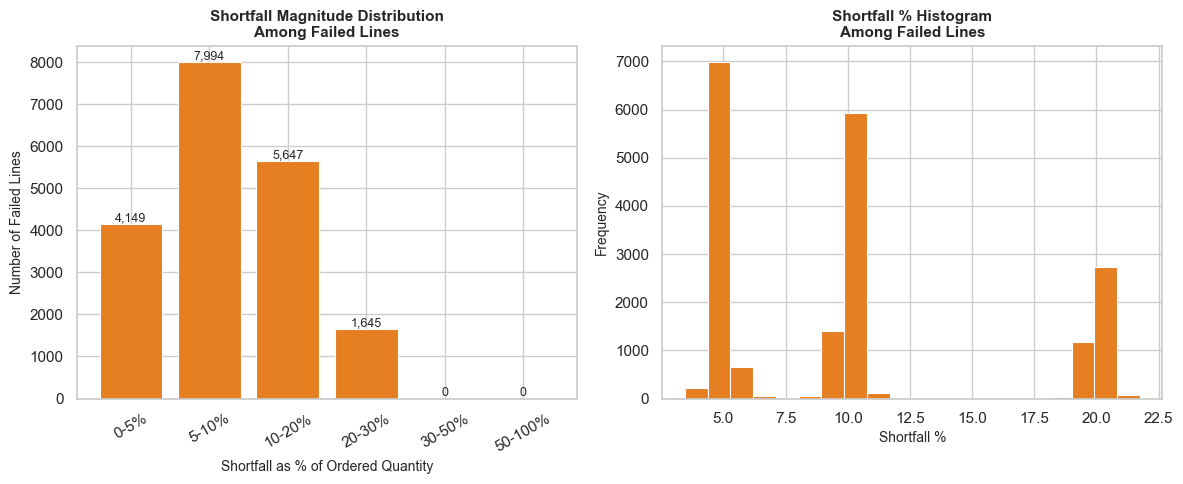

Chart saved.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left - shortfall bucket bar chart
axes[0].bar(
    labels, bucket_counts.values,
    color='#e67e22', edgecolor='white', linewidth=0.8
)
axes[0].set_title('Shortfall Magnitude Distribution\nAmong Failed Lines', 
    fontsize=11, fontweight='bold')
axes[0].set_xlabel('Shortfall as % of Ordered Quantity', fontsize=10)
axes[0].set_ylabel('Number of Failed Lines', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

for i, val in enumerate(bucket_counts.values):
    axes[0].annotate(f'{val:,}', xy=(i, val), 
        ha='center', va='bottom', fontsize=9)

# Right - shortfall pct histogram
axes[1].hist(
    failed_lines['shortfall_pct'],
    bins=20, color='#e67e22',
    edgecolor='white', linewidth=0.8
)
axes[1].set_title('Shortfall % Histogram\nAmong Failed Lines',
    fontsize=11, fontweight='bold')
axes[1].set_xlabel('Shortfall %', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'h3_shortfall_distribution.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

### H3 partially confirmed. Shortfall distribution among 19,435 failed lines shows zero failures above 30% shortfall threshold that means no catastrophic stockouts exist in this dataset. Failures concentrate in the 5-10% range at 41.13%, consistent with warehouse execution errors such as miscounts and mispicks rather than supply collapse. This finding reframes the business problem that AtliQ is not failing due to dramatic supply disruptions but due to thousands of persistent small shortfalls that consistently cross the strict binary IF threshold. Every shortfall regardless of magnitude counts equally as a failed line, which is why LIFR at 65.96% diverges so sharply from VOFR at 96.59%. The fix required is operational precision at warehouse level, not supply chain restructuring.

#### *05. Clustering all 35 customers into distinct failure profiles based on their OT gap and IF gap relative to their individual targets. This segmentation identifies which customers need which type of intervention and surfaces the two structural failure modes identified in 03_core_metrics.ipynb.*

__Customer failure profile clustering__

- Classifying each customer into a failure profile

In [22]:
def classify_profile(row):
    ot_gap = row['OT_gap']
    if_gap = row['IF_gap']
    
    # Both gaps severe
    if ot_gap <= -20 and if_gap <= -20:
        return 'Both Failing'
    # Primarily OT failure
    elif ot_gap <= -20 and if_gap > -20:
        return 'Primarily Late'
    # Primarily IF failure
    elif if_gap <= -20 and ot_gap > -20:
        return 'Primarily Short'
    # Moderate failure on both
    else:
        return 'Moderate Both'

customer_metrics['failure_profile'] = customer_metrics.apply(
    classify_profile, axis=1)

print("CUSTOMER FAILURE PROFILE CLUSTERING\n")
profile_summary = customer_metrics.groupby('failure_profile').agg(
    customer_count = ('customer_id',  'count'),
    avg_ot_gap     = ('OT_gap',       'mean'),
    avg_if_gap     = ('IF_gap',       'mean'),
    avg_otif_gap   = ('OTIF_gap',     'mean')
).round(2).reset_index()

print(profile_summary.to_string(index=False))

print(f"\nCUSTOMERS BY PROFILE\n")
for profile in customer_metrics['failure_profile'].unique():
    group = customer_metrics[
        customer_metrics['failure_profile'] == profile
    ][['customer_name', 'city', 'OT_gap', 'IF_gap', 'OTIF_gap']]
    print(f"\n  Profile: {profile}")
    print(f"  {'-'*60}")
    print(group.to_string(index=False))

CUSTOMER FAILURE PROFILE CLUSTERING

failure_profile  customer_count  avg_ot_gap  avg_if_gap  avg_otif_gap
   Both Failing               7      -32.11      -34.51        -41.16
  Moderate Both               8      -16.29      -16.98        -28.41
 Primarily Late               7      -40.49      -12.67        -37.91
Primarily Short              13      -15.50      -27.64        -35.60

CUSTOMERS BY PROFILE


  Profile: Primarily Short
  ------------------------------------------------------------
 customer_name      city  OT_gap  IF_gap  OTIF_gap
  Vijay Stores     Surat  -13.41  -21.66    -30.88
  Vijay Stores  Vadodara  -17.03  -49.09    -51.45
     Rel Fresh     Surat  -14.42  -24.11    -32.88
     Rel Fresh Ahmedabad  -11.93  -20.38    -28.67
  Atlas Stores Ahmedabad  -13.69  -20.02    -28.68
Chiptec Stores Ahmedabad  -14.59  -20.78    -31.45
   Propel Mart     Surat  -12.16  -20.23    -27.37
   Propel Mart Ahmedabad  -15.00  -20.83    -30.30
 Viveks Stores  Vadodara  -15.79  -21.68

- Scatter plot - OT gap vs IF gap colored by profile

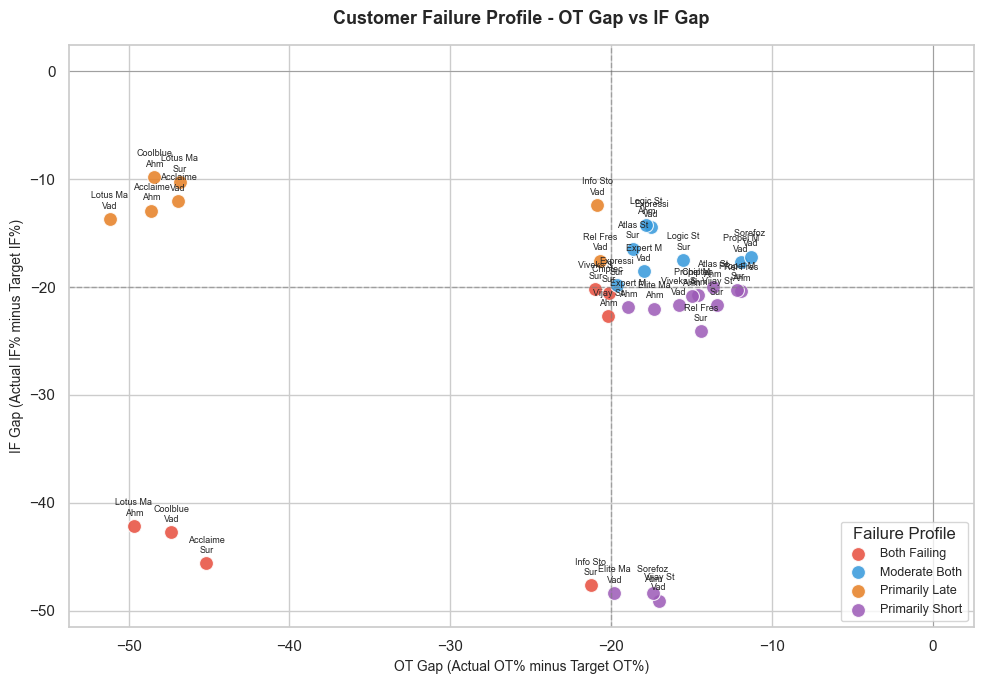

Chart saved.


In [23]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = {
    'Both Failing':    '#e74c3c',
    'Primarily Late':  '#e67e22',
    'Primarily Short': '#9b59b6',
    'Moderate Both':   '#3498db'
}

for profile, group in customer_metrics.groupby('failure_profile'):
    ax.scatter(
        group['OT_gap'], group['IF_gap'],
        label=profile, color=colors[profile],
        s=100, alpha=0.85, edgecolors='white', linewidth=0.8
    )

ax.axhline(y=-20, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(x=-20, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=0,   color='black', linestyle='-',  linewidth=0.5, alpha=0.3)
ax.axvline(x=0,   color='black', linestyle='-',  linewidth=0.5, alpha=0.3)

for _, row in customer_metrics.iterrows():
    ax.annotate(
        f"{row['customer_name'][:8]}\n{row['city'][:3]}",
        xy=(row['OT_gap'], row['IF_gap']),
        fontsize=6.5, ha='center', va='bottom',
        xytext=(0, 6), textcoords='offset points'
    )

ax.set_title('Customer Failure Profile - OT Gap vs IF Gap',
    fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('OT Gap (Actual OT% minus Target OT%)', fontsize=10)
ax.set_ylabel('IF Gap (Actual IF% minus Target IF%)', fontsize=10)
ax.legend(title='Failure Profile', fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'customer_clustering.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

### Customer clustering reveals that the same retail brands experience entirely different failure profiles across cities. Vijay Stores fails Both metrics in Ahmedabad, is Primarily Short in Vadodara with IF gap of -49.09, and is moderate in Surat. Acclaimed Stores is Primarily Late in Ahmedabad and Vadodara but Both Failing in Surat. This city-level inconsistency within the same retail brand confirms that the failure driver is AtliQ's city-level operational execution rather than anything inherent to the customer relationship. A customer receiving inconsistent service quality depending on which city fulfills their order is precisely the type of experience that drives contract non-renewal.

- Cleaner scatter without overlapping labels

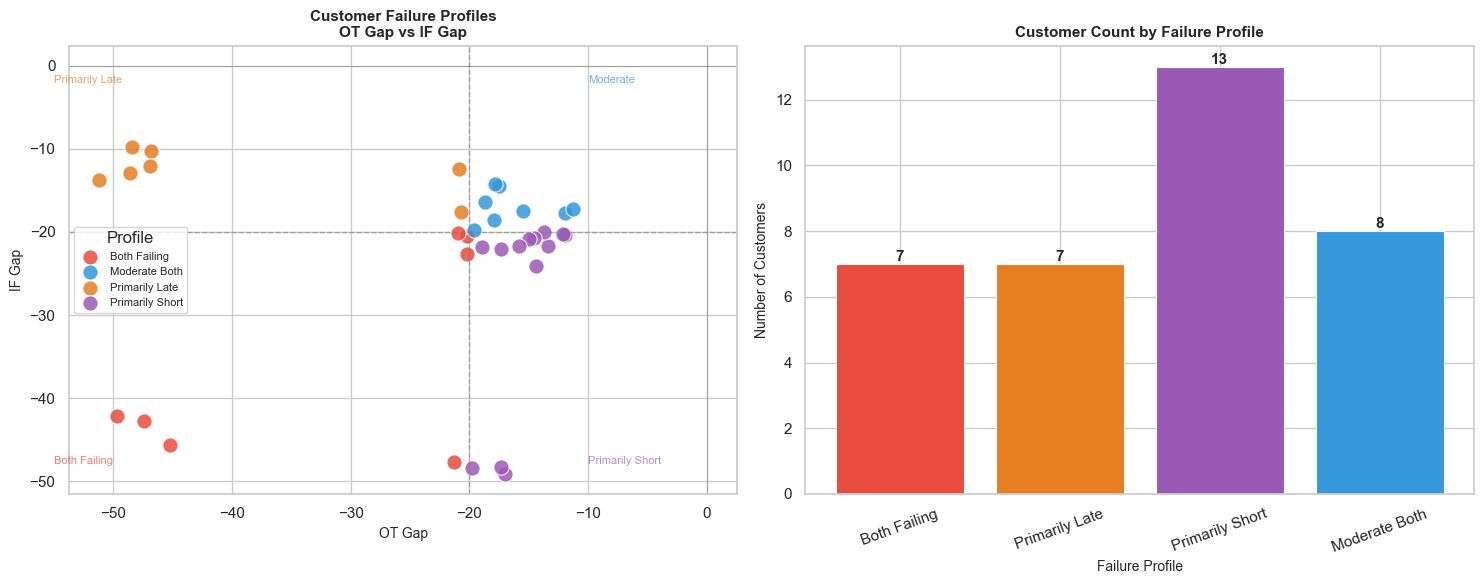

Chart saved.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#Left - scatter plot without individual labels
for profile, group in customer_metrics.groupby('failure_profile'):
    axes[0].scatter(
        group['OT_gap'], group['IF_gap'],
        label=profile, color=colors[profile],
        s=120, alpha=0.85, edgecolors='white', linewidth=0.8
    )

axes[0].axhline(y=-20, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[0].axvline(x=-20, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[0].axhline(y=0,   color='black', linestyle='-',  linewidth=0.5, alpha=0.3)
axes[0].axvline(x=0,   color='black', linestyle='-',  linewidth=0.5, alpha=0.3)

axes[0].set_title('Customer Failure Profiles\nOT Gap vs IF Gap',
    fontsize=11, fontweight='bold')
axes[0].set_xlabel('OT Gap', fontsize=10)
axes[0].set_ylabel('IF Gap', fontsize=10)
axes[0].legend(title='Profile', fontsize=8)

#Annotating quadrants
axes[0].text(-55, -2,  'Primarily Late',  fontsize=8, color='#e67e22', alpha=0.7)
axes[0].text(-10, -2,  'Moderate',        fontsize=8, color='#3498db', alpha=0.7)
axes[0].text(-55, -48, 'Both Failing',    fontsize=8, color='#e74c3c', alpha=0.7)
axes[0].text(-10, -48, 'Primarily Short', fontsize=8, color='#9b59b6', alpha=0.7)

#Right - profile summary bar chart
profile_order = ['Both Failing', 'Primarily Late', 'Primarily Short', 'Moderate Both']
counts = [
    len(customer_metrics[customer_metrics['failure_profile'] == p])
    for p in profile_order
]
bar_colors = [colors[p] for p in profile_order]

bars = axes[1].bar(
    profile_order, counts,
    color=bar_colors, edgecolor='white', linewidth=0.8
)
axes[1].set_title('Customer Count by Failure Profile',
    fontsize=11, fontweight='bold')
axes[1].set_xlabel('Failure Profile', fontsize=10)
axes[1].set_ylabel('Number of Customers', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)

for bar, count in zip(bars, counts):
    axes[1].annotate(
        str(count),
        xy=(bar.get_x() + bar.get_width()/2, count),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'customer_clustering_clean.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

#### *06. Identifying the worst performing product and city combinations by IF failure rate. This pinpoints exactly where AtliQ's supply problems are most acute - which products are failing which cities most severely. These combinations are the highest priority targets for operational intervention.*

__Worst SKU x city combinations__

- Computing IF failure rate per product per city

In [25]:
sku_city = master.groupby(
    ['product_name', 'category', 'city']
).agg(
    total_lines     = ('in_full_line', 'count'),
    lines_in_full   = ('in_full_line', 'sum'),
    total_ordered   = ('order_qty',    'sum'),
    total_delivered = ('delivered_qty','sum'),
    avg_shortfall   = ('shortfall_pct','mean')
).reset_index()

sku_city['LIFR_%']          = (sku_city['lines_in_full'] / sku_city['total_lines']    * 100).round(2)
sku_city['VOFR_%']          = (sku_city['total_delivered']/ sku_city['total_ordered'] * 100).round(2)
sku_city['IF_failure_rate'] = (100 - sku_city['LIFR_%']).round(2)
sku_city['avg_shortfall']   = sku_city['avg_shortfall'].round(2)

- Top 15 worst SKU x city combinations

In [26]:
worst_sku_city = sku_city.sort_values(
    'IF_failure_rate', ascending=False
).head(15)

print("WORST SKU x CITY COMBINATIONS - BY IF FAILURE RATE\n")
print(f"  {'Product':<20} {'Category':<12} {'City':<12} {'Lines':>6} {'LIFR%':>7} {'Failure%':>10} {'Avg Shortfall%':>15}")
print(f"  {'-'*85}")
for _, row in worst_sku_city.iterrows():
    print(f"  {row['product_name']:<20} {row['category']:<12} {row['city']:<12} {row['total_lines']:>6,} {row['LIFR_%']:>7.2f} {row['IF_failure_rate']:>10.2f} {row['avg_shortfall']:>15.2f}")

WORST SKU x CITY COMBINATIONS - BY IF FAILURE RATE

  Product              Category     City          Lines   LIFR%   Failure%  Avg Shortfall%
  -------------------------------------------------------------------------------------
  AM Butter 500        Dairy        Vadodara      1,156   61.76      38.24            3.94
  AM Butter 250        Dairy        Vadodara      1,076   61.99      38.01            3.83
  AM Curd 50           Dairy        Vadodara      1,102   62.25      37.75            3.79
  AM Tea 100           Beverages    Vadodara      1,094   62.61      37.39            3.62
  AM Ghee 250          Dairy        Vadodara      1,073   62.91      37.09            3.77
  AM Ghee 150          Dairy        Vadodara      1,121   63.25      36.75            3.66
  AM Milk 250          Dairy        Vadodara      1,113   63.25      36.75            3.61
  AM Tea 500           Beverages    Vadodara      1,099   63.33      36.67            3.86
  AM Milk 100          Dairy        Vadod

#### *Heatmap of IF failure rate across all 18 products and 3 cities. Red indicates high failure, green indicates relatively better performance. The color gradient immediately surfaces Vadodara as the most supply-constrained city across nearly all products.*

- Heatmap - IF failure rate by product and city

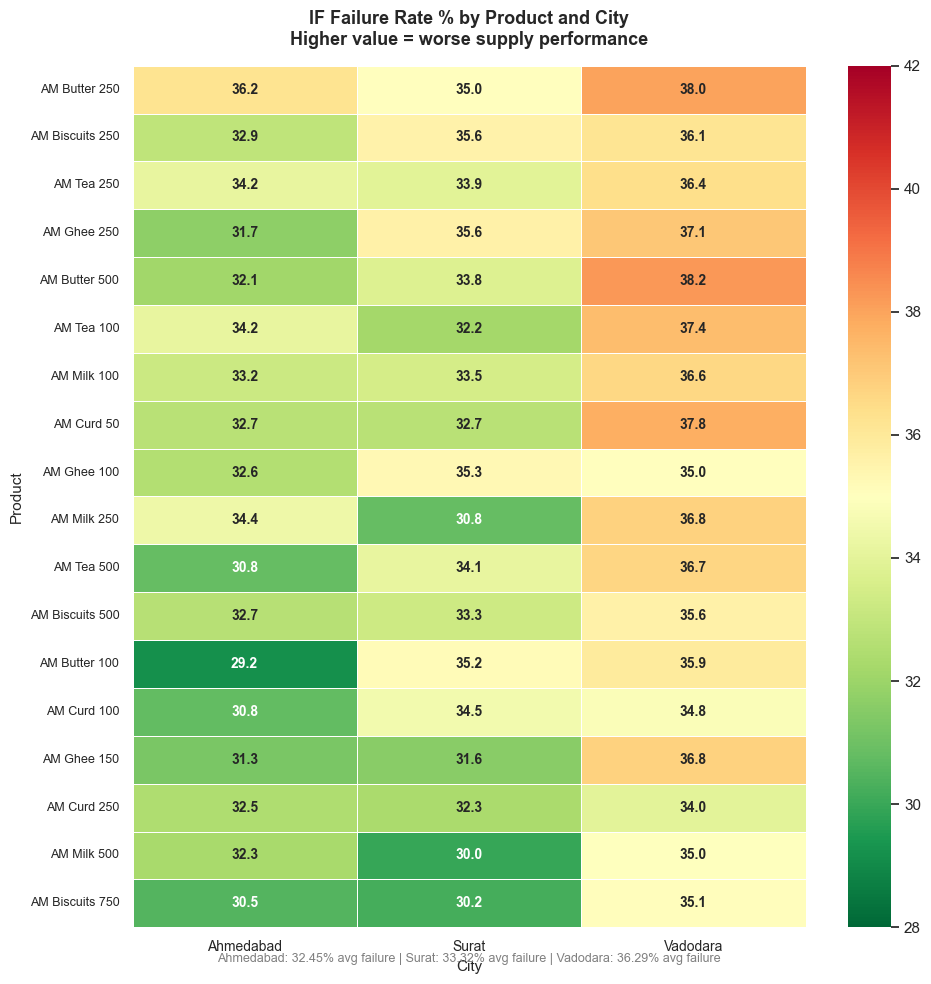

Chart saved.


In [28]:
pivot = sku_city.pivot_table(
    index='product_name',
    columns='city',
    values='IF_failure_rate',
    aggfunc='mean'
).round(2)

#Sorting products by average failure rate across cities (worst at top)
pivot['avg'] = pivot.mean(axis=1)
pivot = pivot.sort_values('avg', ascending=False).drop(columns='avg')

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    pivot,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.6,
    linecolor='white',
    ax=ax,
    vmin=28, vmax=42,
    annot_kws={'size': 10, 'weight': 'bold'}
)

ax.set_title(
    'IF Failure Rate % by Product and City\nHigher value = worse supply performance',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('City', fontsize=11)
ax.set_ylabel('Product', fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=9)

#Adding city-level average at bottom
city_avgs = sku_city.groupby('city')['IF_failure_rate'].mean().round(2)
subtitle = ' | '.join([f"{city}: {avg}% avg failure" for city, avg in city_avgs.items()])
ax.text(
    0.5, -0.04, subtitle,
    transform=ax.transAxes,
    ha='center', fontsize=9, color='gray'
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'sku_city_heatmap.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

### SKU-city analysis delivers the sharpest geographic signal in the entire dataset. Vadodara accounts for 13 of the 15 worst product-city combinations by IF failure rate, representing 14,251 of 16,334 lines in the worst combinations. This contradicts the earlier finding that city gaps were uniform; OT failures are geographically uniform but IF failures are concentrated in Vadodara. This means Vadodara has a specific supply availability problem that other cities do not share at the same severity. Dairy products dominate the worst combinations at 10 of 15, consistent with Dairy being 67% of the SKU catalog. No single product drives the failure; infact, every product fails at similar rates in Vadodara, confirming a city-level supply constraint rather than a product-specific planning failure.

### Saving customer failure profile classifications to outputs folder for use in SQL layer and Power BI customer drilldown page. This table is the foundation of the diagnostic dashboard.

__Saving the Root Cause Analysis outputs__

In [29]:
customer_metrics.to_csv(
    os.path.join(OUTPUT_DIR, 'customer_clustering.csv'), index=False)

sku_city.to_csv(
    os.path.join(OUTPUT_DIR, 'sku_city_metrics.csv'), index=False)

print("RCA OUTPUTS SAVED\n")
for f in sorted(os.listdir(OUTPUT_DIR)):
    filepath = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"  {f:45s}  {size_kb:>6.1f} KB")

RCA OUTPUTS SAVED

  category_metrics.csv                              0.2 KB
  city_metrics.csv                                  0.4 KB
  customer_clustering.csv                           3.8 KB
  customer_clustering.png                         111.8 KB
  customer_clustering_clean.png                   104.6 KB
  customer_metrics.csv                              3.3 KB
  delay_distribution.png                           45.8 KB
  dom_metrics.csv                                   0.2 KB
  h2_simultaneous_failures.png                     68.1 KB
  h2_threshold_sensitivity.png                     56.0 KB
  h3_shortfall_distribution.png                    76.6 KB
  h5_promise_window.png                            37.8 KB
  monthly_metrics.csv                               0.3 KB
  product_metrics.csv                               1.4 KB
  sku_city_heatmap.png                            154.7 KB
  sku_city_metrics.csv                              4.0 KB
